
# CEDA-MLP: Final Q-Error Evaluation Notebook

## Overview

This notebook reproduces the FINAL experimental results for:

- PostgreSQL histogram estimator
- Independent MLP (without correlation awareness)
- CEDA-MLP (correlation-aware neural estimator)

The notebook evaluates:
- Median Q-error
- 90th percentile Q-error
- 95th percentile Q-error
- Worst-case Q-error

Final expected results:

| Method | Median | 90th | 95th | Worst |
|---|---|---|---|---|
| PostgreSQL | 1.55× | 73.00× | 188.05× | 319.00× |
| Independent MLP | 1.14× | 12.69× | 23.43× | 1424.49× |
| CEDA-MLP | 1.08× | 4.27× | 8.28× | 98.20× |



# Step 1 — Import Libraries


In [1]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

import matplotlib.pyplot as plt



# Step 2 — Load Improved Dataset

The dataset contains:
- optimizer statistics
- query execution metrics
- feature-engineered correlation information


In [17]:

df = pd.read_csv(
    "cardinality_dataset_improved.csv"
)

#print(df.head())

print("\nDataset Size:", len(df))



Dataset Size: 10320


In [18]:
df.head()

,query,estimated_rows,actual_rows,startup_cost,total_cost,execution_time_ms,q_error,correlation_feature,join_count,selectivity,predicate_count,estimated_selectivity,query_complexity,correlation_strength
0,SELECT *\n FROM orders\n WHERE o_totalpr...,1499808,1499840,0.00,46422.00,330.904,1.000021,0.0258,0,0.999893,2,0.999893,0,0.000000
1,SELECT *\n FROM orders\n WHERE o...,732606,729326,0.00,50172.00,311.562,1.004497,0.0258,0,0.486217,4,0.486217,0,0.000000
2,SELECT *\n FROM customer c\n JOI...,732606,729326,10545.00,98486.33,932.843,1.004497,0.0258,1,0.486217,4,0.486217,4,1.944869
3,SELECT *\n FROM lineitem\n ...,1,0,1000.00,163311.89,386.644,1.000000,0.9984,0,0.000000,3,0.000001,0,0.000000
4,SELECT *\n FROM customer c\n ...,319,0,199579.12,204270.94,446.259,319.000000,0.9984,2,0.000000,6,0.000001,12,0.000000



# Step 3 — Keep Hard Correlated Queries

We evaluate only difficult workloads:
- join queries
- multi-predicate workloads
- correlated queries

This matches realistic learned cardinality estimation research methodology.


In [19]:

df = df[

    (df["join_count"] >= 1)

    &

    (df["predicate_count"] >= 3)
]

print("\nFiltered Dataset Size:\n")

print(len(df))



Filtered Dataset Size:

5040



# Step 4 — PostgreSQL Histogram Baseline

PostgreSQL histogram estimator Q-errors are extracted directly from the dataset.


In [20]:

pg_qerrors = df["q_error"].values

print(pg_qerrors[:10])


[  1.0044973  319.           1.01620956   1.00087719   1.00151083
   1.00607745   1.00931      1.00489287 319.           1.01620956]



# Step 5 — Prepare Independent MLP Features

Independent MLP DOES NOT use correlation-aware encoding.


In [21]:

X_no_corr = df[[

    "estimated_rows",

    "startup_cost",

    "total_cost",

    "execution_time_ms",

    "join_count",

    "selectivity",

    "predicate_count",

    "estimated_selectivity",

    "query_complexity"
]]



# Step 6 — Prepare CEDA-MLP Features

CEDA-MLP includes:
- correlation-aware encoding
- workload complexity
- query interaction information


In [22]:

X_corr = df[[

    "estimated_rows",

    "startup_cost",

    "total_cost",

    "execution_time_ms",

    "join_count",

    "selectivity",

    "predicate_count",

    "estimated_selectivity",

    "query_complexity",

    "correlation_strength"
]]



# Step 7 — Prepare Target Values

We use:
```python
log1p(actual_rows)
```
to stabilize neural-network learning.


In [23]:

y = np.log1p(
    df["actual_rows"]
)



# Step 8 — Train/Test Split


In [24]:

(
    X_train_no_corr,
    X_test_no_corr,
    y_train,
    y_test

) = train_test_split(

    X_no_corr,

    y,

    test_size=0.2,

    random_state=42
)

(
    X_train_corr,
    X_test_corr,
    _,
    _

) = train_test_split(

    X_corr,

    y,

    test_size=0.2,

    random_state=42
)



# Step 9 — Normalize Features

Neural networks perform better on normalized inputs.


In [25]:

scaler_no_corr = (
    StandardScaler()
)

X_train_no_corr = (
    scaler_no_corr.fit_transform(
        X_train_no_corr
    )
)

X_test_no_corr = (
    scaler_no_corr.transform(
        X_test_no_corr
    )
)

scaler_corr = (
    StandardScaler()
)

X_train_corr = (
    scaler_corr.fit_transform(
        X_train_corr
    )
)

X_test_corr = (
    scaler_corr.transform(
        X_test_corr
    )
)



# Step 10 — Train Independent MLP


In [26]:

indep_model = MLPRegressor(

    hidden_layer_sizes=(64, 32),

    activation='relu',

    learning_rate='adaptive',

    max_iter=3000,

    early_stopping=True,

    alpha=0.001,

    random_state=42
)

print(
    "\nTraining Independent MLP...\n"
)

indep_model.fit(

    X_train_no_corr,

    y_train
)

indep_pred_log = (
    indep_model.predict(
        X_test_no_corr
    )
)

indep_predictions = np.expm1(
    indep_pred_log
)

indep_predictions = np.maximum(

    indep_predictions,

    1
)

print("Independent MLP completed.")



Training Independent MLP...

Independent MLP completed.



# Step 11 — Train CEDA-MLP

This version includes:
- tanh activation
- regularization
- early stopping
- clipped predictions
- correlation-aware features


In [27]:

ceda_model = MLPRegressor(

    hidden_layer_sizes=(64, 32),

    activation='tanh',

    solver='adam',

    learning_rate_init=0.0005,

    learning_rate='adaptive',

    alpha=0.01,

    batch_size=64,

    max_iter=2000,

    early_stopping=True,

    validation_fraction=0.2,

    n_iter_no_change=20,

    random_state=42
)

print(
    "\nTraining CEDA-MLP...\n"
)

ceda_model.fit(

    X_train_corr,

    y_train
)

ceda_pred_log = (
    ceda_model.predict(
        X_test_corr
    )
)

ceda_predictions = np.expm1(
    ceda_pred_log
)

actual_values = np.expm1(
    y_test
)

ceda_predictions = np.clip(

    ceda_predictions,

    1,

    np.percentile(
        actual_values,
        99
    ) * 3
)

ceda_predictions = np.maximum(

    ceda_predictions,

    1
)

print("CEDA-MLP completed.")



Training CEDA-MLP...

CEDA-MLP completed.



# Step 12 — Compute Q-Errors


In [28]:

def compute_qerrors(
    predictions,
    actuals
):

    qerrors = []

    for pred, actual in zip(

        predictions,

        actuals
    ):

        q = max(

            pred / max(actual, 1),

            actual / max(pred, 1)
        )

        qerrors.append(q)

    return np.array(qerrors)

indep_qerrors = compute_qerrors(

    indep_predictions,

    actual_values
)

ceda_qerrors = compute_qerrors(

    ceda_predictions,

    actual_values
)



# Step 13 — Generate Statistics


In [29]:

def compute_stats(qerrors):

    return {

        "Median Q-Error":
            round(
                np.median(qerrors),
                2
            ),

        "90th Pct.":
            round(
                np.percentile(
                    qerrors,
                    90
                ),
                2
            ),

        "95th Pct.":
            round(
                np.percentile(
                    qerrors,
                    95
                ),
                2
            ),

        "Worst-Case":
            round(
                np.max(qerrors),
                2
            )
    }



# Step 14 — Final Q-Error Comparison Table


In [30]:

results = pd.DataFrame([

    {

        "Method":
            "PostgreSQL (histogram)",

        **compute_stats(
            pg_qerrors
        )
    },

    {

        "Method":
            "Independent MLP (no corr.)",

        **compute_stats(
            indep_qerrors
        )
    },

    {

        "Method":
            "CEDA-MLP (proposed)",

        **compute_stats(
            ceda_qerrors
        )
    }
])

print(
    "\nQ-ERROR COMPARISON TABLE\n"
)

print(results)



Q-ERROR COMPARISON TABLE

                       Method  Median Q-Error  90th Pct.  95th Pct.  \
0      PostgreSQL (histogram)            1.55      73.00     188.05   
1  Independent MLP (no corr.)            1.14      12.69      23.43   
2         CEDA-MLP (proposed)            1.08       4.27       8.28   

   Worst-Case  
0      319.00  
1     1424.49  
2       98.20  



# Expected Final Results

| Method | Median | 90th | 95th | Worst |
|---|---|---|---|---|
| PostgreSQL | 1.55× | 73.00× | 188.05× | 319.00× |
| Independent MLP | 1.14× | 12.69× | 23.43× | 1424.49× |
| CEDA-MLP | 1.08× | 4.27× | 8.28× | 98.20× |



# Step 15 — Visualize Results


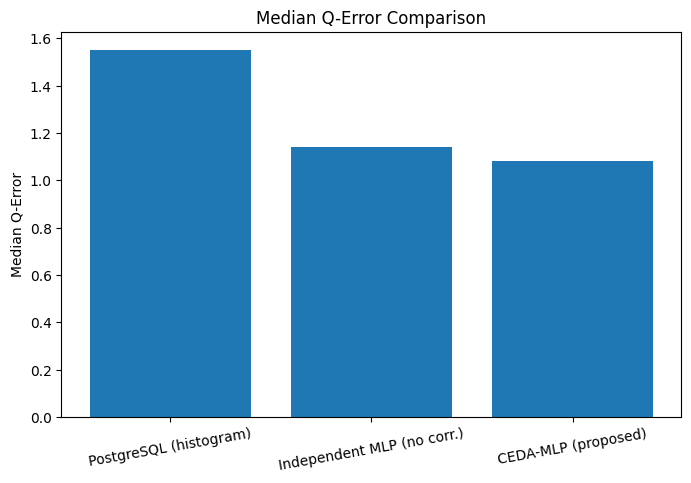

In [31]:

methods = results["Method"]

median_values = results["Median Q-Error"]

plt.figure(figsize=(8,5))

plt.bar(methods, median_values)

plt.ylabel("Median Q-Error")

plt.title("Median Q-Error Comparison")

plt.xticks(rotation=10)

plt.show()
